In [1]:
# Importamos las librerias necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual global para todos los gráficos
sns.set_theme(style="whitegrid")

In [2]:
# Cargamos el dataset principal
df = pd.read_csv("Data/steam.csv")

In [3]:
# Primera exploración: forma del dataset
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print()

# Ver las primeras filas
df.head(10)

Filas: 27075
Columnas: 18



,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99
5,60,Ricochet,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Valve Anti-Ch...,Action,Action;FPS;Multiplayer,0,2758,684,175,10,5000000-10000000,3.99
6,70,Half-Life,1998-11-08,1,Valve,Valve,windows;mac;linux,0,Single-player;Multi-player;Online Multi-Player...,Action,FPS;Classic;Action,0,27755,1100,1300,83,5000000-10000000,7.19
7,80,Counter-Strike: Condition Zero,2004-03-01,1,Valve,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,Action;FPS;Multiplayer,0,12120,1439,427,43,10000000-20000000,7.19
8,130,Half-Life: Blue Shift,2001-06-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player,Action,FPS;Action;Sci-fi,0,3822,420,361,205,5000000-10000000,3.99
9,220,Half-Life 2,2004-11-16,1,Valve,Valve,windows;mac;linux,0,Single-player;Steam Achievements;Steam Trading...,Action,FPS;Action;Sci-fi,33,67902,2419,691,402,10000000-20000000,7.19


In [4]:
# Ver el tipo de dato de cada columna
df.dtypes

appid                 int64
name                 object
release_date         object
english               int64
developer            object
publisher            object
platforms            object
required_age          int64
categories           object
genres               object
steamspy_tags        object
achievements          int64
positive_ratings      int64
negative_ratings      int64
average_playtime      int64
median_playtime       int64
owners               object
price               float64
dtype: object

In [5]:
# Resumen estadístico de las columnas numéricas
df.describe()

,appid,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


In [6]:
# Comprobar nulos por columna
df.isnull().sum()

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64

In [7]:
# Convertimos release_date de texto a formato fecha
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

# Comprobamos que el cambio se ha hecho correctamente
print(df["release_date"].dtype)
df["release_date"].head()

datetime64[ns]


0   2000-11-01
1   1999-04-01
2   2003-05-01
3   2001-06-01
4   1999-11-01
Name: release_date, dtype: datetime64[ns]

In [8]:
# Creamos una columna nueva con solo el año
df["release_year"] = df["release_date"].dt.year

# Comprobamos
df[["name", "release_date", "release_year"]].head()

,name,release_date,release_year
0,Counter-Strike,2000-11-01,2000
1,Team Fortress Classic,1999-04-01,1999
2,Day of Defeat,2003-05-01,2003
3,Deathmatch Classic,2001-06-01,2001
4,Half-Life: Opposing Force,1999-11-01,1999


In [9]:
# Función que convierte el rango "10000000-20000000" en su valor medio
def parse_owners(owners_str):
    partes = owners_str.split("-")
    minimo = int(partes[0])
    maximo = int(partes[1])
    return (minimo + maximo) / 2

# Aplicamos la funcion a toda la columna y creamos una columna nueva
df["owners_mean"] = df["owners"].apply(parse_owners)

# Comprobamos 
df[["name", "owners", "owners_mean"]].head()

,name,owners,owners_mean
0,Counter-Strike,10000000-20000000,15000000.0
1,Team Fortress Classic,5000000-10000000,7500000.0
2,Day of Defeat,5000000-10000000,7500000.0
3,Deathmatch Classic,5000000-10000000,7500000.0
4,Half-Life: Opposing Force,5000000-10000000,7500000.0


In [10]:
# Creamos uan columna con el porcentaje de valoraciones positivas
df["positive_ratio"] = ( 
    df["positive_ratings"] / (df["positive_ratings"] + df["negative_ratings"])
) * 100

# Comprobamos
df[["name", "positive_ratings", "negative_ratings", "positive_ratio"]].head()

,name,positive_ratings,negative_ratings,positive_ratio
0,Counter-Strike,124534,3339,97.388815
1,Team Fortress Classic,3318,633,83.978740
2,Day of Defeat,3416,398,89.564761
3,Deathmatch Classic,1273,267,82.662338
4,Half-Life: Opposing Force,5250,288,94.799567


In [11]:
# ¿Por qué esta columna? Un juego con 10.000 valoraciones positivas no es igual de bueno si tiene 1.000 negativas que si tiene 100.000. El ratio nos da una métrica justa independientemente del volumen, y la usaremos para responder varias preguntas de negocio.

In [12]:
# Resumen del dataset después de la limpieza
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"\nColumnas actuales:\n{list(df.columns)}")
print(f"\nNulos restantes:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Filas: 27075
Columnas: 21

Columnas actuales:
['appid', 'name', 'release_date', 'english', 'developer', 'publisher', 'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'owners', 'price', 'release_year', 'owners_mean', 'positive_ratio']

Nulos restantes:
developer     1
publisher    14
dtype: int64


---
### 1. ¿Cómo ha evolucionado la cantidad de juegos publicados por año?


In [13]:
# Contamos cuántos juegos se publicaron cada año.
juegos_por_año = df.groupby("release_year")["appid"].count().reset_index()
juegos_por_año.columns = ["año", "num_juegos"]

juegos_por_año

,año,num_juegos
0,1997,1
1,1998,1
2,1999,2
3,2000,2
4,2001,4
5,2002,1
6,2003,3
7,2004,6
8,2005,6
9,2006,48


- **Los primeros años (1997 -2005):** Son juegos muy antiguos que Valve añadió a Steam de forma retroactiva. No son representativos del mercado actual.
- **2019:** El dataset se extrajo en *mayo de 2019*, así que solo tiene 2 meses de datos, no el año completo. Por eso parece que "cae".

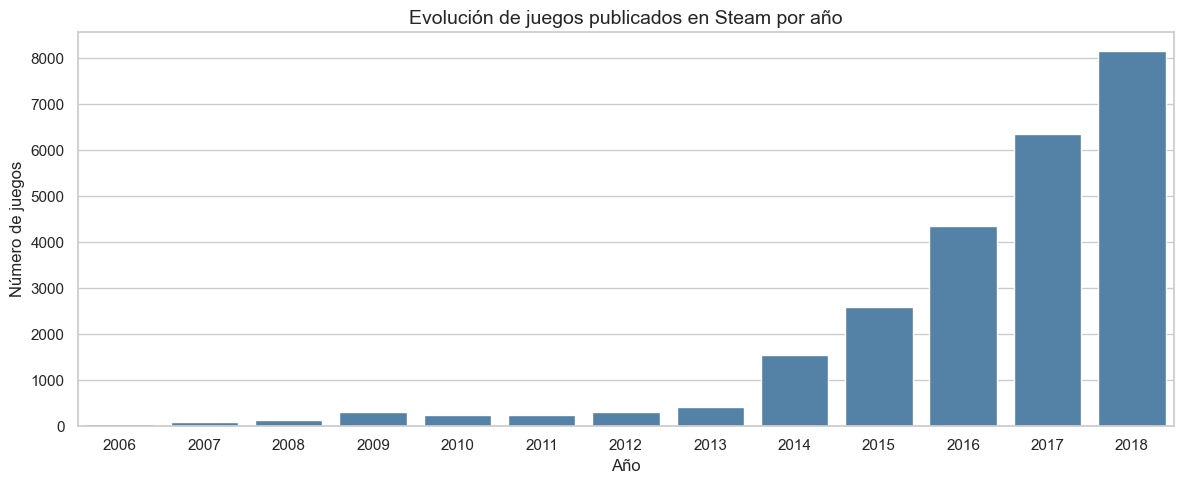

In [14]:
# Filtramos: desde 2006 (Cuando Steam abre a terceros) hasta 2018 (año completo más reciente)
juegos_por_año_filtrado = juegos_por_año[
    (juegos_por_año["año"] >= 2006) & (juegos_por_año["año"] <= 2018)
     ]

# Visualización.
fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(data=juegos_por_año_filtrado, x="año", y="num_juegos", ax=ax, color="steelblue")

ax.set_title("Evolución de juegos publicados en Steam por año", fontsize=14)
ax.set_xlabel("Año")
ax.set_ylabel("Número de juegos")

plt.tight_layout()
plt.savefig("img/01_juegos_por_año.png", dpi=150, bbox_inches="tight")
plt.show()

### 📌 Conclusiones — Evolución de juegos por año

- El catálogo de Steam creció de forma moderada entre 2006 y 2013.
- A partir de 2014 el crecimiento se disparó, coincidiendo con la llegada de **Steam Greenlight** (2012), 
  un programa que permitía a desarrolladores independientes publicar sus juegos con el voto de la comunidad.
- En 2018 se publicaron más de 8.000 juegos, el máximo histórico del dataset.
- Los datos anteriores a 2006 y el año 2019 fueron excluidos por no ser representativos.

---
### 2. ¿Qué géneros dominan el mercado y cuáles tiene mejor valoración?

In [15]:
# Aquí hay un pequeño reto: "genres" tiene valores como "Action;Adventure;RPG" en una sola celda. Para analizar géneros necesitamos separar eso.

In [16]:
# Separamos los géneros y creamos una fila por cada género de cada juego.
genres_expanded = df["genres"].str.split(";").explode()

# Contamos cuántos juegos hay por género
generos_conteo = genres_expanded.value_counts().reset_index()
generos_conteo.columns = ["genero", "num_juegos"]

generos_conteo

,genero,num_juegos
0,Indie,19421
1,Action,11903
2,Casual,10210
3,Adventure,10032
4,Strategy,5247
5,Simulation,5194
6,RPG,4311
7,Early Access,2954
8,Free to Play,1704
9,Sports,1322


Interesante. Hay algo importante a destacar: **Indie**, **Early Access**, **Free to Play**, **Violent**, **Gore**, **Nudity** y **Sexual Content** no son géneros reales, son etiquetas de Steam. Para el analisis de géneros conviene filtrarlos.

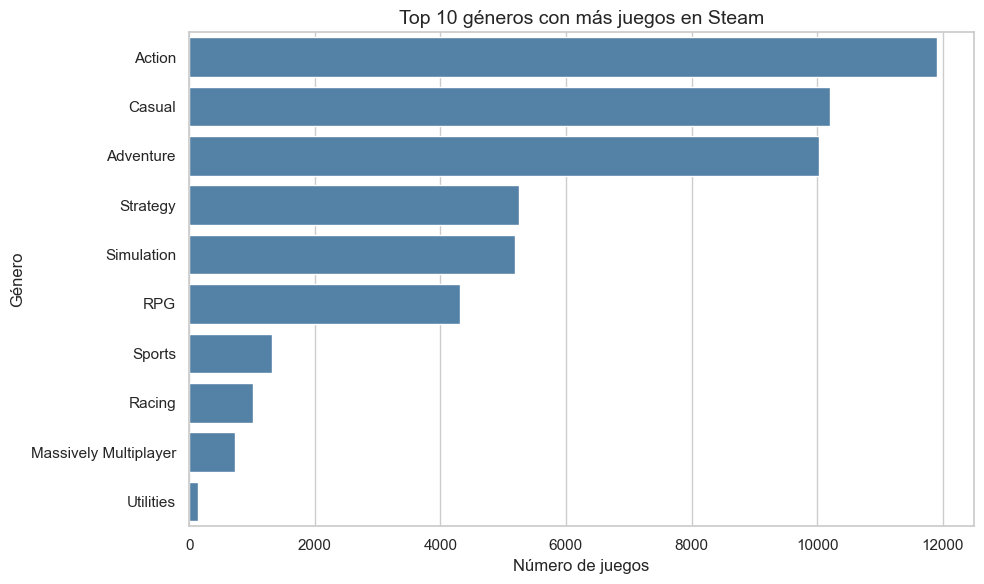

In [17]:
# Etiquetas que no son géneros reales
no_generos = ["Indie", "Early Access", "Free to Play", "Violent", "Gore", "Nudity", "Sexual Content"]

# Filtramos
generos_limpios = generos_conteo[~generos_conteo["genero"].isin(no_generos)].head(10)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=generos_limpios, x="num_juegos", y="genero", ax=ax, color= "steelblue")

ax.set_title("Top 10 géneros con más juegos en Steam", fontsize=14)
ax.set_xlabel("Número de juegos")
ax.set_ylabel("Género")

plt.tight_layout()
plt.savefig("img/02_top_generos.png", dpi=150, bbox_inches="tight")
plt.show()

### Action domina claramente, seguido por Casual y Adventure muy igualados.
#### Ahora vamos con la segunda parte de la pregunta: ¿Qué géneros tienen mejor valoración?

In [18]:
# Necesitamos combinar géneros con el positive_ratio del dataframe original.
# Para eso creamos un dataframe expandido con una fila por género por juego
df_genres_expanded = df[["appid", "genres", "positive_ratio"]].copy()
df_genres_expanded["genero"] = df_genres_expanded["genres"].str.split(";")
df_genres_expanded = df_genres_expanded.explode("genero")

# Filtramos las etiquetas que no son géneros reales
df_genres_expanded = df_genres_expanded[~df_genres_expanded["genero"].isin(no_generos)]

# Calculamos la valoración media por género (solo géneros con más de 100 juegos)
valoracion_por_genero = (
    df_genres_expanded.groupby("genero")["positive_ratio"]
    .agg(media="mean", num_juegos="count")
    .reset_index()
)

valoracion_por_genero = valoracion_por_genero[valoracion_por_genero["num_juegos"] > 100]
valoracion_por_genero = valoracion_por_genero.sort_values("media", ascending=False)

valoracion_por_genero

,genero,media,num_juegos
12,RPG,71.626058,4311
2,Adventure,71.375304,10032
5,Casual,71.066363,10210
1,Action,70.988826,11903
17,Strategy,69.291369,5247
19,Utilities,68.846705,146
13,Racing,66.719598,1024
16,Sports,66.604025,1322
14,Simulation,65.983492,5194
10,Massively Multiplayer,61.189327,723


### Los géneros están bastante igualados entre el 65-72%, con RPG a la cabeza y los MMOs siendo el peor valorado. 

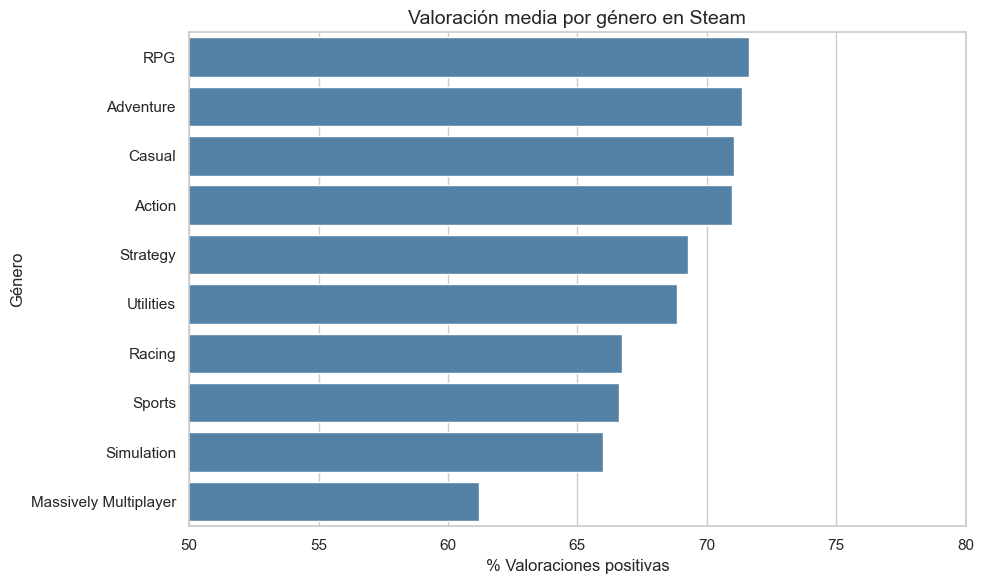

In [19]:
# Visualización

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=valoracion_por_genero,
    x="media",
    y="genero",
    ax=ax,
    color="steelblue"
)

ax.set_title("Valoración media por género en Steam", fontsize=14)
ax.set_xlabel("% Valoraciones positivas")
ax.set_ylabel("Género")
ax.set_xlim(50, 80) # Limitamos el eje para que las diferencias se vean mejor.

plt.tight_layout()
plt.savefig("img/03_valoracion_por_genero.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusiones - Géneros en Steam

**Cantidad de juegos:**  
- Action es el género dominante con casi 12.000 juegos, seguido de Casual y Adventure.
- Existe una gran brecha entre los 3 primeros géneros y el resto.

**Valoración:**
- Los géneros mejor valorados son RPG, Adventure y Casual, todos por encima del 71%.
- Massively Multiplayer es el peor valorado (61%), posiblemente por la dificultad de mantener servidores y comunidades activas a lo largo plazo.
- Las diferencias entre géneros son relativamente pequeñas (61-72%), lo que sugiere que el género por sí solo no es el factor determinando del éxito.

---
### 3. ¿Existe relación entre el precio de un juego y su valoración?

In [20]:
# Primero voy a explorar la columna de price.
print(f"Precio mínimo:{df['price'].min()}")
print(f"Precio máximo:{df['price'].max()}")
print(f"Precio medio:{df['price'].mean():.2f}")
print(f"Juegos gratuitos(precio = 0):{(df['price'] == 0).sum()}")
print(f"Juegos de pago: {(df['price'] > 0).sum()}")

Precio mínimo:0.0
Precio máximo:421.99
Precio medio:6.08
Juegos gratuitos(precio = 0):2560
Juegos de pago: 24515


421,99 es una sorpresa. Casi con toda seguridad son DLCs, packs de contenido o software profesional que se cuelta en el dataset, no juegos normales  

El precio medio de 6,08 está muy distorsionado por juegos gratuitos y los precios extremos.

In [21]:
# Filtramos juegos de pago y eliminaos precios extremos (por encima de 70 dolares)
df_pago = df[(df["price"] > 0) & (df["price"] <= 70)].copy()

print(f"Juegos tras el filtro: {len(df_pago)}")
print(f"Precio máximo tras el filtro: {df_pago['price'].max()}")

Juegos tras el filtro: 24495
Precio máximo tras el filtro: 69.99


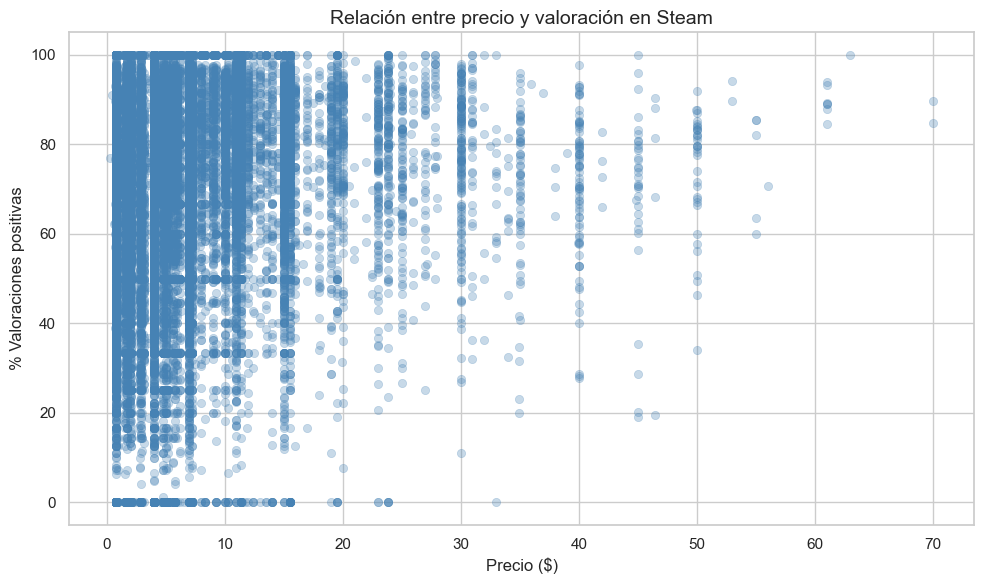

In [22]:
# Visualización

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_pago,
    x="price",
    y="positive_ratio",
    ax=ax,
    alpha=0.3,
    color="steelblue",
    edgecolor=None
)

ax.set_title("Relación entre precio y valoración en Steam", fontsize=14)
ax.set_xlabel("Precio ($)")
ax.set_ylabel("% Valoraciones positivas")

plt.tight_layout()
plt.savefig("img/04_precio_vs_valoraciones.png", dpi=150, bbox_inches="tight")
plt.show()


- La mayoría de juegos se concentran entre 0-20$
- A partir de 20$ hay muchos menos juegos pero se distribuyen por todo el rango de valoraciones
- No se aprecia una tendencia clara visualmente

Correlación precio vs valoración: 0.100


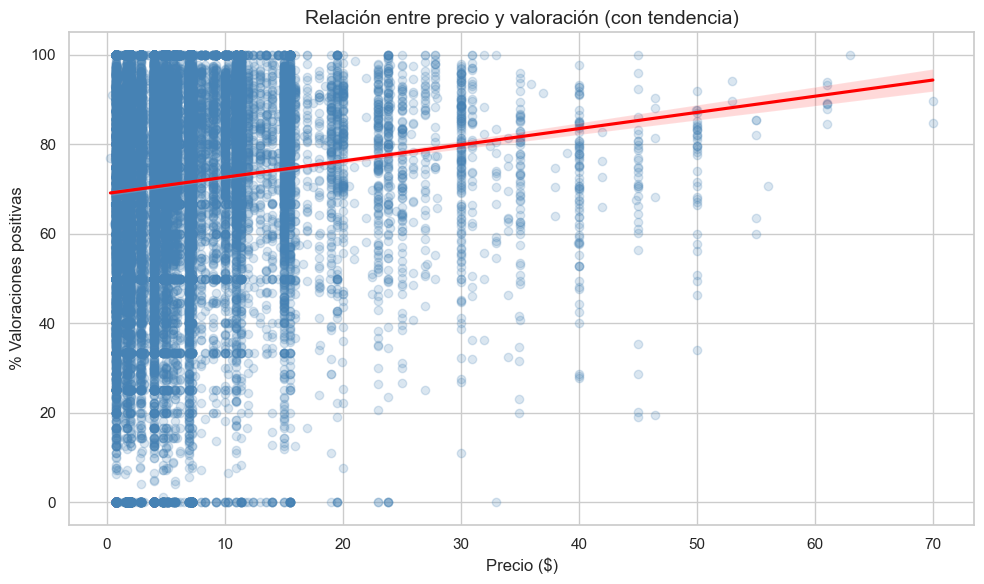

In [23]:
# Calculamos la correlación entre precio y valoración
correlacion= df_pago["price"].corr(df_pago["positive_ratio"])
print(f"Correlación precio vs valoración: {correlacion:.3f}")

# Mismo g´rafico añadiendo línea de tendencia
fig, ax = plt.subplots(figsize=(10,6))

sns.regplot(
    data=df_pago,
    x="price",
    y="positive_ratio",
    ax=ax,
    scatter_kws={"alpha":0.2, "color": "steelblue", "edgecolor": None},
    line_kws={"color": "red"}
)

ax.set_title("Relación entre precio y valoración (con tendencia)", fontsize=14)
ax.set_xlabel("Precio ($)")
ax.set_ylabel("% Valoraciones positivas")

plt.tight_layout()
plt.savefig("img/05_precio_vs_valoracion_tendencia.png", dpi=150, bbox_inches="tight")
plt.show()


### Conclusiones - Precio vs Valoración

- La correlación entre precio y valoración es de **0.10**, practicamente inexistente.
- El precio por si solo **no determina** la calidad percebida de un juego.
- La mayoria de juegos se concentran en el rango0-20$, donde la dispersión de valoraciones es máxima (desde 0% hasta 100%).
- Los juegos más caros (+40$) tienden a evitar las valoraciones muy bajas, posiblemente porque los grandes estudios tienen más recursos para garantizar una calidad mínima.
- **Conclusión clave:** Un juego barato puede ser excelente y uno caro puede ser malo. El precio no es un indicador de calidad en Steam. 
--- 

### 4. ¿Qué desarroladores tienen mejor ratio calidad-precio?

In [24]:
# Filtramos desarroladores con al menos 5 juegos de pago para que sea representativo.
devs = df[df["price"] > 0].groupby("developer").agg(
    num_juegos=("appid", "count"),
    valoracion_media=("positive_ratio", "mean"),
    precio_medio=("price", "mean")
).reset_index()

devs = devs[devs["num_juegos"] >=5]
# ¿Por qué 5? Un desarollador con 1 juego muy bien valorado no nos dice nada sobre su consistencia. Con 5 juegos mínimo podemos hablar de un patrón real.

print(f"Desarrolladores con 5 o más juegos de pago: {len(devs)}")
devs.head(10)

Desarrolladores con 5 o más juegos de pago: 584


,developer,num_juegos,valoracion_media,precio_medio
8,07th Expansion,9,95.804777,10.490000
18,10tons Ltd,14,81.884801,7.732857
20,11 bit studios,7,84.337139,10.775714
42,1C Entertainment,10,68.982394,3.710000
48,1C:InoCo,5,70.836841,3.350000
105,3000AD,5,19.982090,6.990000
116,3D Realms (Apogee Software),7,81.171305,4.132857
119,3DDUO,7,55.277159,3.361429
241,ACE Team,6,80.325922,9.656667
247,AFBIK Studio,16,67.583087,0.846250


In [28]:
# Creamos una métrica calidad-precio: valoración entre precio
# Un juego con 80% de valoración a 5$ tiene mejor ratio que uno con 80% a 40$
devs["ratio_calidad_precio"] = devs["valoracion_media"] / devs["precio_medio"]

# Top 10 desarrolladores con mejor ratio
top_devs = devs.sort_values("ratio_calidad_precio", ascending=False).head(10)

top_devs[["developer", "num_juegos", "valoracion_media", "precio_medio", "ratio_calidad_precio"]]

,developer,num_juegos,valoracion_media,precio_medio,ratio_calidad_precio
15255,凝冰剑斩,7,94.333096,0.790000,119.408983
9729,Pirotexnik,5,92.121568,0.790000,116.609580
2825,Crew Lab,12,90.759519,0.790000,114.885467
9007,NukGames,9,85.015282,0.790000,107.614281
9694,Pilgrim Adventures;GrabTheGames Studios,5,87.794720,0.818000,107.328509
2411,Chris Antoni,5,84.522949,0.790000,106.991074
8796,Nickervision Studios,8,96.652526,0.952500,101.472468
4325,FailoutGames,5,80.000000,0.790000,101.265823
9418,Paleno Games,6,75.497270,0.788333,95.768207
15213,КиКо,10,73.745090,0.790000,93.348215


In [29]:
# Interesante, pero hay un problema claro: casi todos tienen un precio medio de 0.79$, que es el precio mínimo en Steam. La métrica está siendo dominada por el precio más que por la valoración.
# Necesitamos un filtro de preio mínimo para que el ratio sea más justo.

In [31]:
# Filtramos desarrolladores con precio medio superior a 3$
# para evitar que los juegos a 0,79$ dominen el ranking
devs_filtrado = devs[devs["precio_medio"] >= 3].sort_values(
    "ratio_calidad_precio", ascending=False
).head(10)

print(devs_filtrado[["developer", "num_juegos", "valoracion_media", "precio_medio", "ratio_calidad_precio"]])

                   developer  num_juegos  valoracion_media  precio_medio  \
4343   Fallen Tree Games Ltd           6         96.253219      3.606667   
9805                Pixeljam           6         87.439117      3.390000   
10446                Realore          16         78.121851      3.115000   
14533                  Zojoi           8         75.353281      3.115000   
6824            Kedronic UAB           5         92.000000      4.090000   
8515          Mykhail Konokh           8         69.368044      3.115000   
12817      The Revills Games           6         76.587522      3.440000   
14709        e-FunSoft Games          13         85.329670      3.836154   
5838            Hosted Games          42         72.556067      3.285238   
13084           Tonguç Bodur          11         70.865593      3.271818   

       ratio_calidad_precio  
4343              26.687584  
9805              25.793250  
10446             25.079246  
14533             24.190459  
6824         

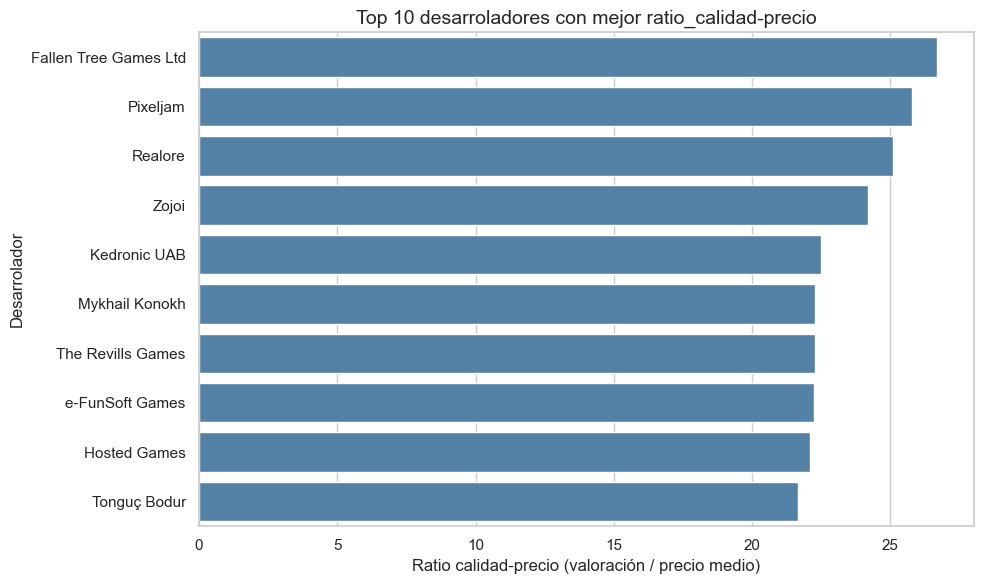

In [32]:
# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=devs_filtrado,
    x="ratio_calidad_precio",
    y="developer",
    ax=ax,
    color="steelblue"
)

ax.set_title("Top 10 desarroladores con mejor ratio_calidad-precio", fontsize=14)
ax.set_xlabel("Ratio calidad-precio (valoración / precio medio)")
ax.set_ylabel("Desarrolador")

plt.tight_layout()
plt.savefig("img/06_top_devs_calidad_precio.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusiones - Desarrolladores con mejor ratio calidad-precio 

- **Fallen Tree Games Ltd** lidera el ranking con un 96% de valoración positiva a un precio medio de 3.6$, siendo el desarrolador indie con mejor relación calidad-precio del dataset.
- El top 10 está dominado por **estudios independientes pequeños**, ningún gran estudio AAA aparece en este ranking. 
- Este tiene sentido: los grandes estudios cobran precios más altos (20-70$) aunque tengan buenas valoraciones, lo que penaliza su ratio. 
- **Hosted GAmes** destaca por tener 42 juegos manteniendo una valoración media del 72%, lo que demuestra consistencia en su catálogo. 
- **Conclusión clave:** Los estudios indie pequeños ofrecen la mejor relación calidad-precio en Steam. 

In [33]:
# Voy a filtrar los estudios indies para ver como les va a las compañias AAA

In [37]:
#  Filtremos desarroladores con precio medio superior a 15$
grandes_estudios = devs[devs["precio_medio"] >= 15].sort_values(
    "ratio_calidad_precio", ascending=False
).head(15)
grandes_estudios[["developer", "num_juegos", "valoracion_media", "precio_medio", "ratio_calidad_precio"]]

,developer,num_juegos,valoracion_media,precio_medio,ratio_calidad_precio
13775,VisualArts/Key,7,96.726298,15.532857,6.227206
1359,Beamdog,5,85.928469,15.090000,5.694398
10976,SEGA,11,85.201201,15.844545,5.377321
12184,Studio Saizensen,6,81.404357,15.323333,5.312444
4172,Eugen Systems,7,78.737749,15.847143,4.968577
5984,"INTI CREATES CO., LTD.",6,87.610670,17.823333,4.915504
13179,Traveller's Tales,8,81.034051,16.490000,4.914133
3077,Daedalic Entertainment,19,84.370525,17.700526,4.766555
10453,Rebellion,12,82.675965,17.506667,4.722542
6031,Idea Factory,8,76.434946,16.215000,4.713842


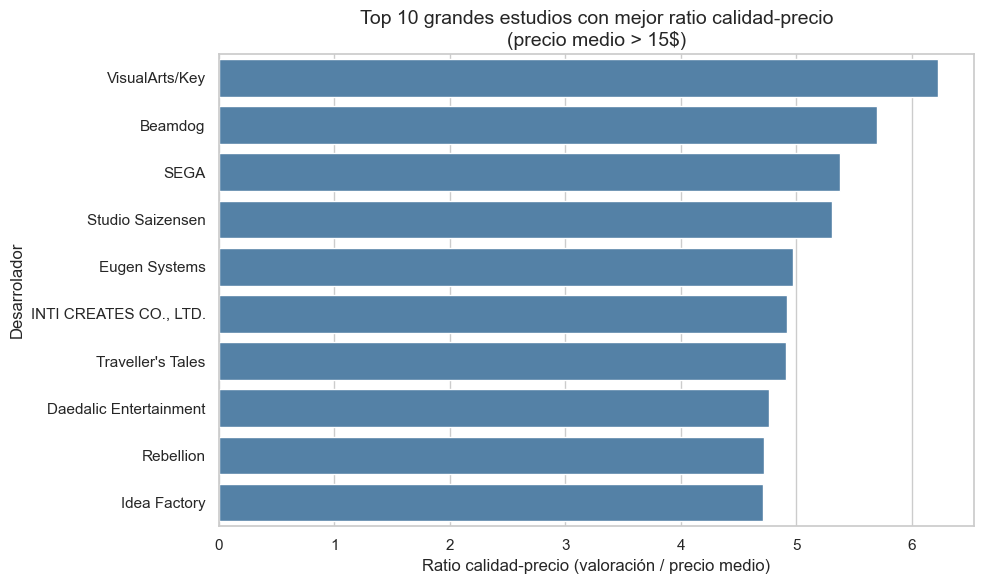

In [39]:
# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=grandes_estudios.head(10),
    x="ratio_calidad_precio",
    y="developer",
    ax=ax,
    color="steelblue"
)

ax.set_title("Top 10 grandes estudios con mejor ratio calidad-precio\n(precio medio > 15$)", fontsize=14)
ax.set_xlabel("Ratio calidad-precio (valoración / precio medio)")
ax.set_ylabel("Desarrolador")

plt.tight_layout()
plt.savefig("img/07_top_grandes_estudios_calidad_precio.png", dpi=150, bbox_inches="tight")
plt.show()

### Apéndice - Grandes estudios vs Indies: ratio calidad-precio

- El mejor gran estudios(**VisualArts/key**) tiene un ratio de 6.2, frente al 26.7 del mejor indie (Fallen Tree Games).
- Los grandes estudios tienen **4-5 veces peor ratio** que los indies, principalmente por sus precios más elevados (15-18$ de media).
- Entre los grandes estudios reconocibles destacan **SEGA** (3º) y **Traveller's Tales** (LEGO games, 7º) con buenas valoraciones.
- **Capcom**, a pesar de ser uno de los estudios más valorados de la industria, no llega al top 10 por sus precios más altos.
- **Conclusión clave:** El modelo indie de precio bajo + calidad alta supera sistemáticamente al modelo AAA en términos de ratio calidad-precio, aunque no en volumen de ventas ni facturación absoluta. 
---

### 5. ¿Los juegos gratuitos tienen peor valoración que los de pago?

In [42]:
# Cramos una columna que clasifica los juegos en gratuitos o de pago
df["tipo_precio"] = df["price"].apply(lambda x: "Gratuito" if x == 0 else "De pago")

# Comparamos la valoración media de cada grupo
comparación = df.groupby("tipo_precio")["positive_ratio"].agg(
    media="mean",
    mediana="median",
    num_juegos="count"
).reset_index()

comparación

,tipo_precio,media,mediana,num_juegos
0,De pago,71.399948,76.470588,24515
1,Gratuito,71.905960,73.514979,2560


In [43]:
# La diferencia es prácticamente inexistente. Los juegos gratuitos tienen incluso una media ligeramente superior.

C:\Users\rukas\AppData\Local\Temp\ipykernel_1696\326650987.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


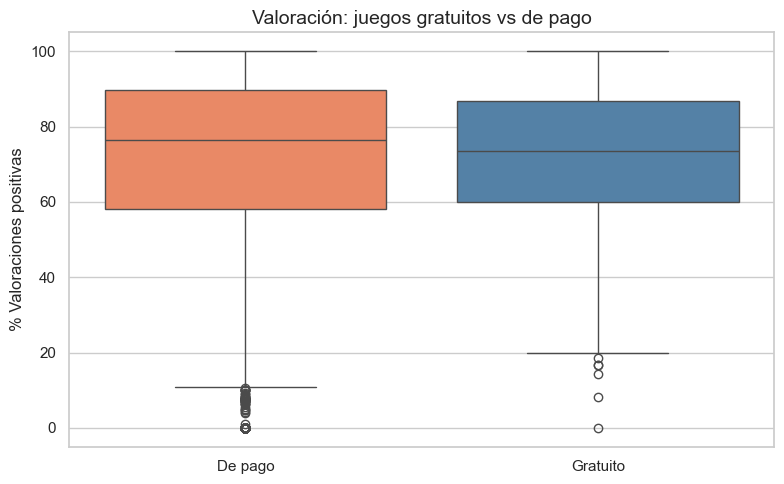

In [46]:
# Visualización
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(
    data=df,
    x="tipo_precio",
    y="positive_ratio",
    ax=ax,
    palette={"Gratuito": "steelblue", "De pago": "coral"}
)

ax.set_title("Valoración: juegos gratuitos vs de pago", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("% Valoraciones positivas")

plt.tight_layout()
plt.savefig("img/08_gratuitos_vs_pago.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusiones - Juegos gratuitos vs de pago

- La diferencia en valoración media es mínima: **71.9% gratuitos vs 71.4% de pago**.
- La hipótesis de que los juegos gratuitos son peor valorados queda **refutada**.
- Los juegos de pago tienen más valores extremos hacia abajo (cerca del 0%), posiblemente porque los jugadores que pagan son más exigentes y se seienten más defraudados cuando el juego no cumple expectativas. 
- Los juegos gratuitos muestran una distribución algo más concretada, lo que sugiere menos sorpresas en ambos extremos.
- **Conclusión clave:** El modelo gratuito no impica menor calidad percibida. La calidad de un juego es independiente de su modelo de negocio. 
---

## 🏁 Conclusiones Generales del EDA

### Contexto
Análisis exploratorio de **27.075 juegos de Steam** publicados entre 1997 y 2019, 
con foco en valoraciones, precios, géneros y desarrolladores.

---

### Hallazgos principales

**📅 Evolución del mercado**
- El catálogo de Steam creció exponencialmente a partir de 2014, pasando de 
  418 juegos ese año a más de 8.000 en 2018.
- La apertura de Steam a desarrolladores independientes transformó completamente 
  el mercado de videojuegos para PC.

**🎮 Géneros**
- Action domina en cantidad con casi 12.000 juegos, pero RPG lidera en valoración 
  con un 71.6% de valoraciones positivas.
- Las diferencias de valoración entre géneros son pequeñas (61-72%), 
  lo que indica que el género no es el factor determinante del éxito.

**💰 Precio y calidad**
- La correlación entre precio y valoración es de apenas 0.10, prácticamente inexistente.
- Un juego caro no garantiza calidad ni un juego barato implica mala experiencia.

**🏆 Desarrolladores**
- Los estudios indie con precios bajos (3-5$) dominan el ratio calidad-precio, 
  con valores hasta 4-5 veces superiores a los grandes estudios.
- Entre los grandes estudios (precio medio > 15$), SEGA y VisualArts/Key 
  destacan como los más eficientes en calidad-precio.

**🆓 Modelo de negocio**
- Los juegos gratuitos tienen una valoración media (71.9%) prácticamente 
  idéntica a los de pago (71.4%).
- El modelo de negocio no determina la calidad percibida por los jugadores.

---

### Conclusión final
> El éxito en Steam no depende del precio ni del género, sino de la 
> calidad del producto. El mercado indie demuestra que es posible 
> competir con grandes estudios ofreciendo experiencias de calidad 
> a precios accesibles.

---

### Próximos pasos
- Visualización interactiva en **Looker Studio** con los datos limpios.
- Posible análisis de **tiempo de juego** como indicador de engagement.
- Exploración del dataset de **tags de SteamSpy** para análisis más granular.

---

In [47]:
# Exportamos el dataframe limpio a CSV para usar en Looker Studio
df.to_csv("Data/steam_limpio.csv", index=False)

print("✅ Archivo exportado correctamente")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Columnas exportadas: {list(df.columns)}")

✅ Archivo exportado correctamente
Filas: 27075
Columnas: 22
Columnas exportadas: ['appid', 'name', 'release_date', 'english', 'developer', 'publisher', 'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'owners', 'price', 'release_year', 'owners_mean', 'positive_ratio', 'tipo_precio']


---
📊 **Dashboard interactivo:** [Ver en Looker Studio](https://datastudio.google.com/reporting/ab6719b0-4b61-44e4-8cf1-93a09eb5ac91)